In [ ]:
Gregory_Cooper_Advanced_Big_Data_and_Data_Mining_Lab_IV

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
#load the data
diabetes = load_diabetes()

X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name='target')

In [6]:
X.shape
X.head()
X.describe

<bound method NDFrame.describe of           age       sex       bmi        bp        s1        s2        s3  \
0    0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1   -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2    0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3   -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4    0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   
..        ...       ...       ...       ...       ...       ...       ...   
437  0.041708  0.050680  0.019662  0.059744 -0.005697 -0.002566 -0.028674   
438 -0.005515  0.050680 -0.015906 -0.067642  0.049341  0.079165 -0.028674   
439  0.041708  0.050680 -0.015906  0.017293 -0.037344 -0.013840 -0.024993   
440 -0.045472 -0.044642  0.039062  0.001215  0.016318  0.015283 -0.028674   
441 -0.045472 -0.044642 -0.073030 -0.081413  0.083740  0.027809  0.173816   

           s4        s5        s6  
0   -

In [7]:
print("Missing values per column:")
print(X.isnull().sum())

Missing values per column:
age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64


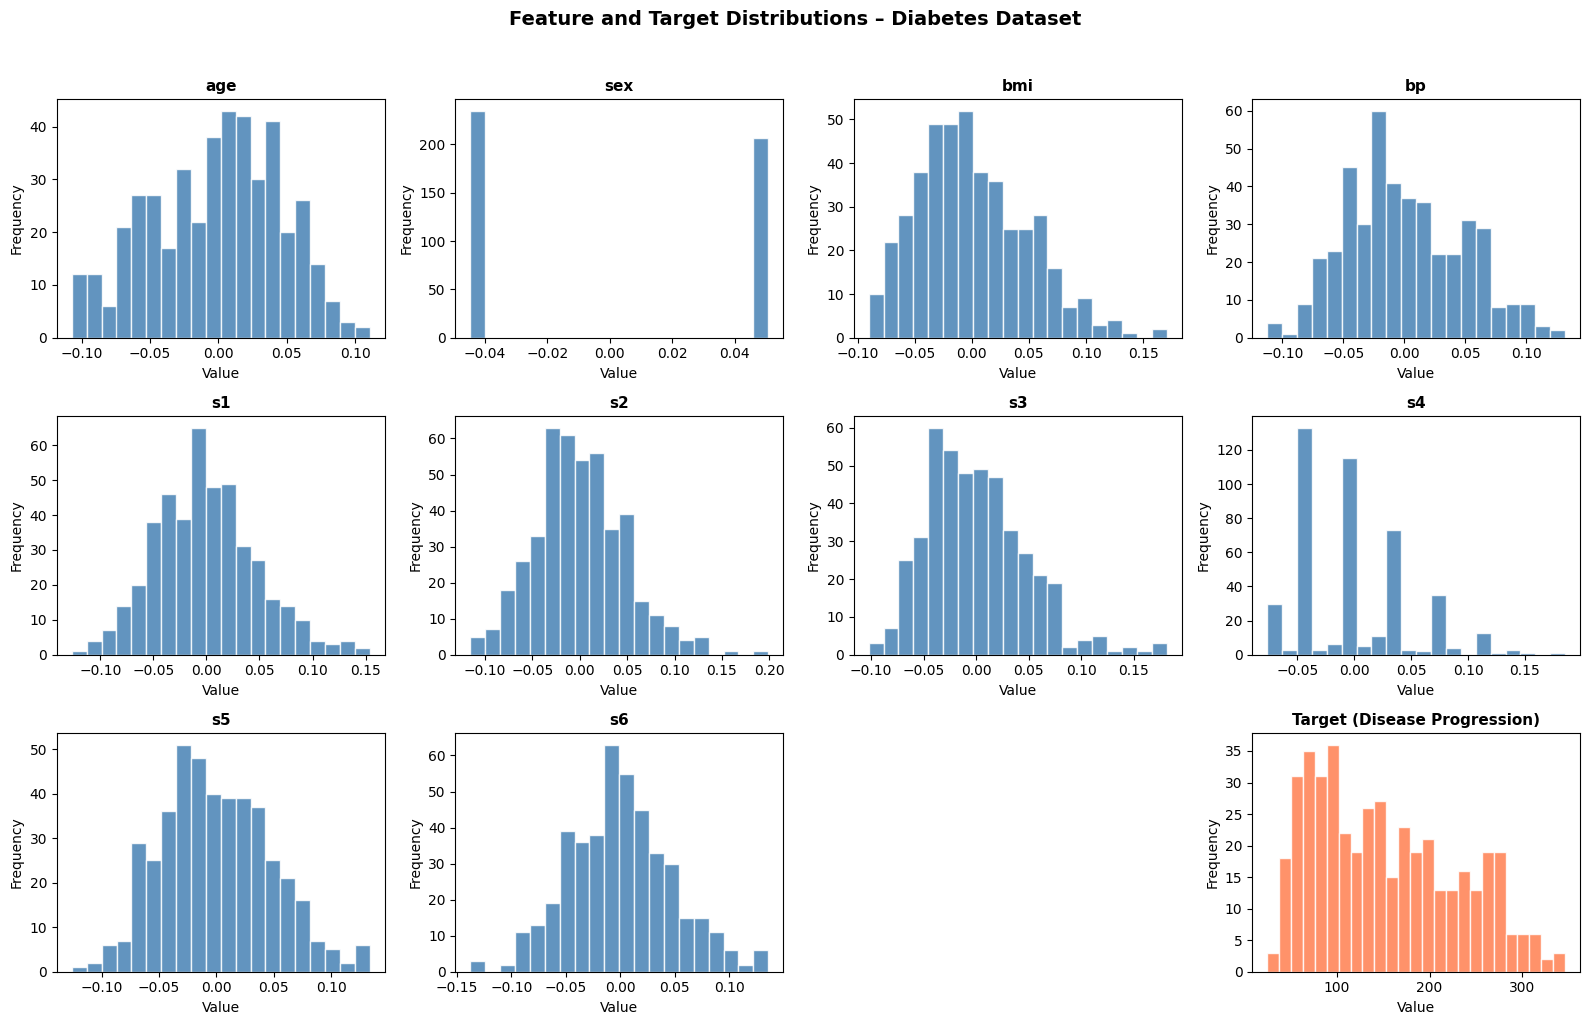

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    axes[i].hist(X[col], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Target distribution in the last subplot
axes[-1].hist(y, bins=25, color='coral', edgecolor='white', alpha=0.85)
axes[-1].set_title('Target (Disease Progression)', fontsize=11, fontweight='bold')
axes[-1].set_xlabel('Value')
axes[-1].set_ylabel('Frequency')

# Hide the unused 11th subplot
axes[-2].set_visible(False)

plt.suptitle('Feature and Target Distributions – Diabetes Dataset', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distributions.png', dpi=120, bbox_inches='tight')
plt.show()

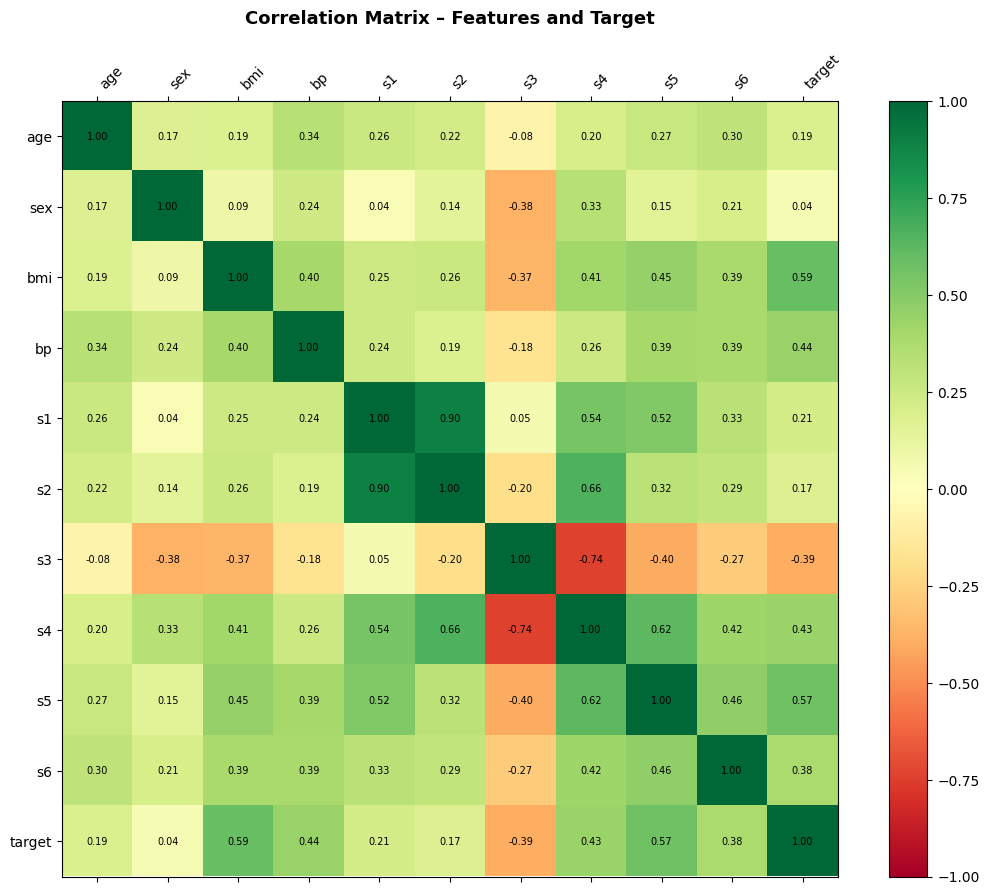


Correlation with target (sorted):
bmi    0.586
s5     0.566
bp     0.441
s4     0.430
s6     0.382
s1     0.212
age    0.188
s2     0.174
sex    0.043
s3    -0.395
Name: target, dtype: float64


In [9]:
#HeatMap correlation


import matplotlib.colors as mcolors

full_df = X.copy()
full_df['target'] = y
corr = full_df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
cax = ax.matshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(cax)
labels = list(corr.columns)
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='left', fontsize=10)
ax.set_yticklabels(labels, fontsize=10)
ax.set_title('Correlation Matrix – Features and Target', fontsize=13, fontweight='bold', pad=20)

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nCorrelation with target (sorted):")
print(corr['target'].drop('target').sort_values(ascending=False).round(3))

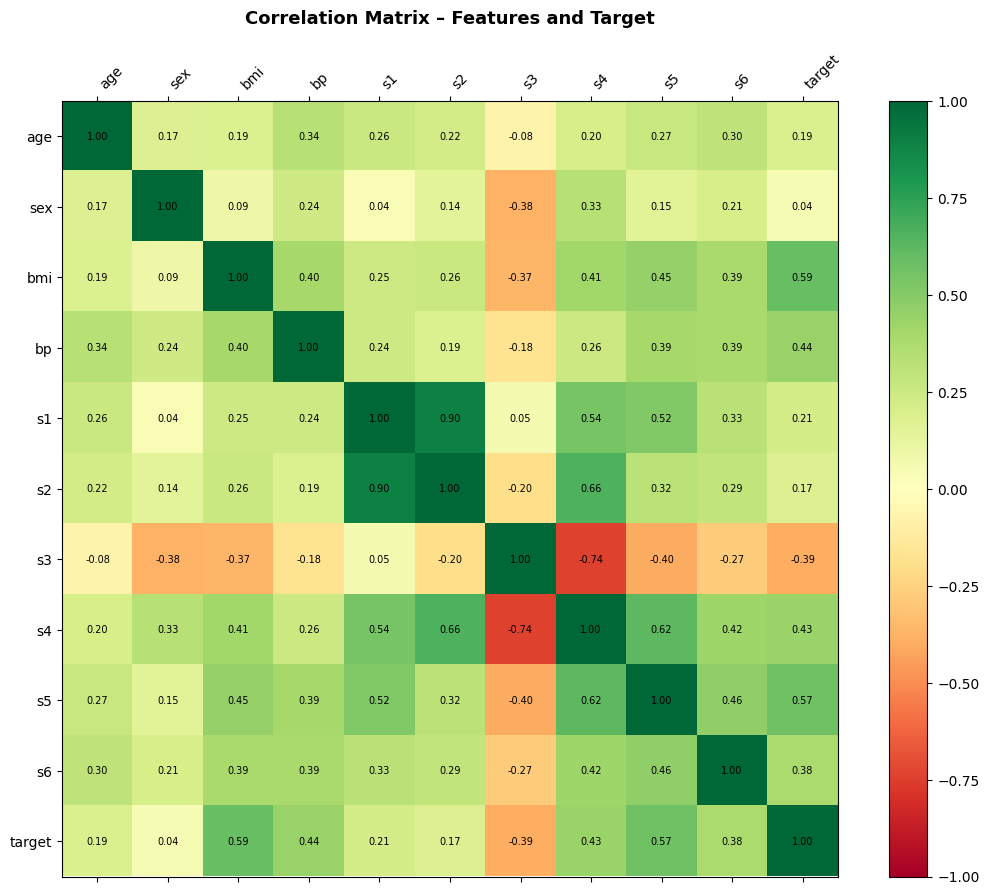


Correlation with target (sorted):
bmi    0.586
s5     0.566
bp     0.441
s4     0.430
s6     0.382
s1     0.212
age    0.188
s2     0.174
sex    0.043
s3    -0.395
Name: target, dtype: float64


In [10]:
import matplotlib.colors as mcolors

full_df = X.copy()
full_df['target'] = y
corr = full_df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
cax = ax.matshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(cax)
labels = list(corr.columns)
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='left', fontsize=10)
ax.set_yticklabels(labels, fontsize=10)
ax.set_title('Correlation Matrix – Features and Target', fontsize=13, fontweight='bold', pad=20)

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nCorrelation with target (sorted):")
print(corr['target'].drop('target').sort_values(ascending=False).round(3))

In [13]:

def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f"{'─'*45}")
    print(f"  Model  : {name}")
    print(f"  MAE    : {mae:.4f}")
    print(f"  MSE    : {mse:.4f}")
    print(f"  RMSE   : {rmse:.4f}")
    print(f"  R²     : {r2:.4f}")
    print(f"{'─'*45}")
    return {'Model': name, 'MAE': round(mae,4), 'MSE': round(mse,4),
            'RMSE': round(rmse,4), 'R2': round(r2,4)}

results = []   # will collect all model results
feature_slr = 'bmi'
X_slr = X[[feature_slr]]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_slr, y, test_size=0.2, random_state=42
)

slr = LinearRegression()
slr.fit(X_train_s, y_train_s)
y_pred_s = slr.predict(X_test_s)

print(f"Coefficient (bmi): {slr.coef_[0]:.4f}")
print(f"Intercept       : {slr.intercept_:.4f}")
res = evaluate('Simple Linear Regression (BMI)', y_test_s, y_pred_s)
results.append(res)

Coefficient (bmi): 998.5777
Intercept       : 152.0034
─────────────────────────────────────────────
  Model  : Simple Linear Regression (BMI)
  MAE    : 52.2600
  MSE    : 4061.8259
  RMSE   : 63.7325
  R²     : 0.2334
─────────────────────────────────────────────


/Users/gregorycooper/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


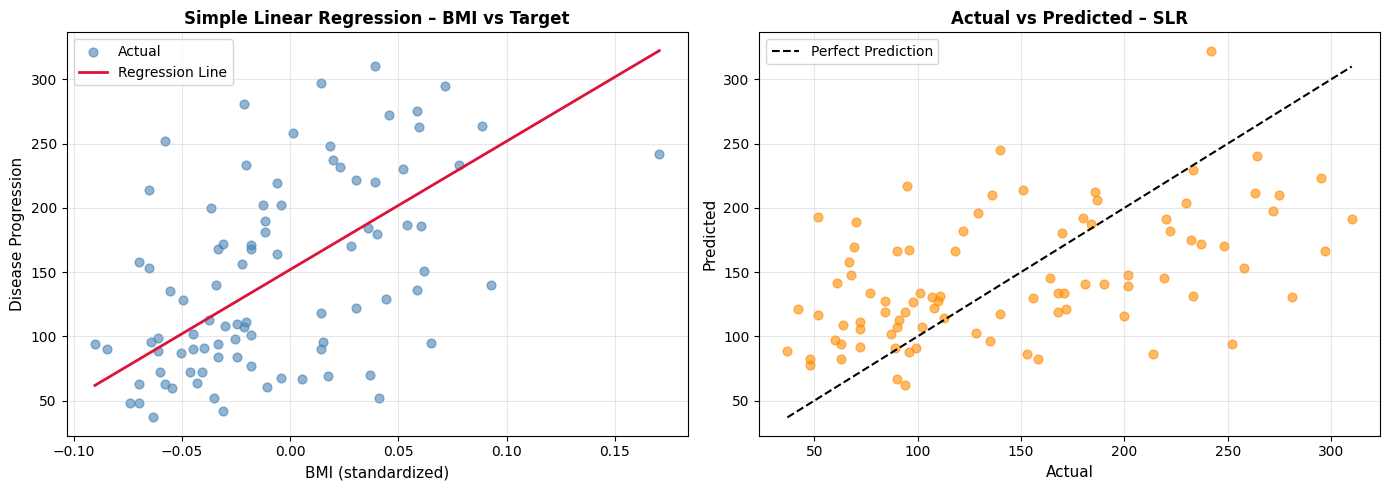

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter + regression line
x_range = np.linspace(X_test_s[feature_slr].min(), X_test_s[feature_slr].max(), 200).reshape(-1,1)
y_range = slr.predict(x_range)

axes[0].scatter(X_test_s[feature_slr], y_test_s, color='steelblue', alpha=0.6, label='Actual', s=40)
axes[0].plot(x_range, y_range, color='crimson', linewidth=2, label='Regression Line')
axes[0].set_xlabel('BMI (standardized)', fontsize=11)
axes[0].set_ylabel('Disease Progression', fontsize=11)
axes[0].set_title('Simple Linear Regression – BMI vs Target', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Actual vs Predicted
axes[1].scatter(y_test_s, y_pred_s, color='darkorange', alpha=0.6, s=40)
mn, mx = y_test_s.min(), y_test_s.max()
axes[1].plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Perfect Prediction')
axes[1].set_xlabel('Actual', fontsize=11)
axes[1].set_ylabel('Predicted', fontsize=11)
axes[1].set_title('Actual vs Predicted – SLR', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('slr_results.png', dpi=120, bbox_inches='tight')
plt.show()

In [16]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y, test_size=0.2, random_state=42
)

mlr = LinearRegression()
mlr.fit(X_train_m, y_train_m)
y_pred_m = mlr.predict(X_test_m)

print("Coefficients:")
for name, coef in zip(X.columns, mlr.coef_):
    print(f"  {name:>6s}: {coef:+.4f}")
print(f"  Intercept: {mlr.intercept_:.4f}")
print()
res = evaluate('Multiple Linear Regression', y_test_m, y_pred_m)
results.append(res)

Coefficients:
     age: +37.9040
     sex: -241.9644
     bmi: +542.4288
      bp: +347.7038
      s1: -931.4888
      s2: +518.0623
      s3: +163.4200
      s4: +275.3179
      s5: +736.1989
      s6: +48.6707
  Intercept: 151.3456

─────────────────────────────────────────────
  Model  : Multiple Linear Regression
  MAE    : 42.7941
  MSE    : 2900.1936
  RMSE   : 53.8534
  R²     : 0.4526
─────────────────────────────────────────────


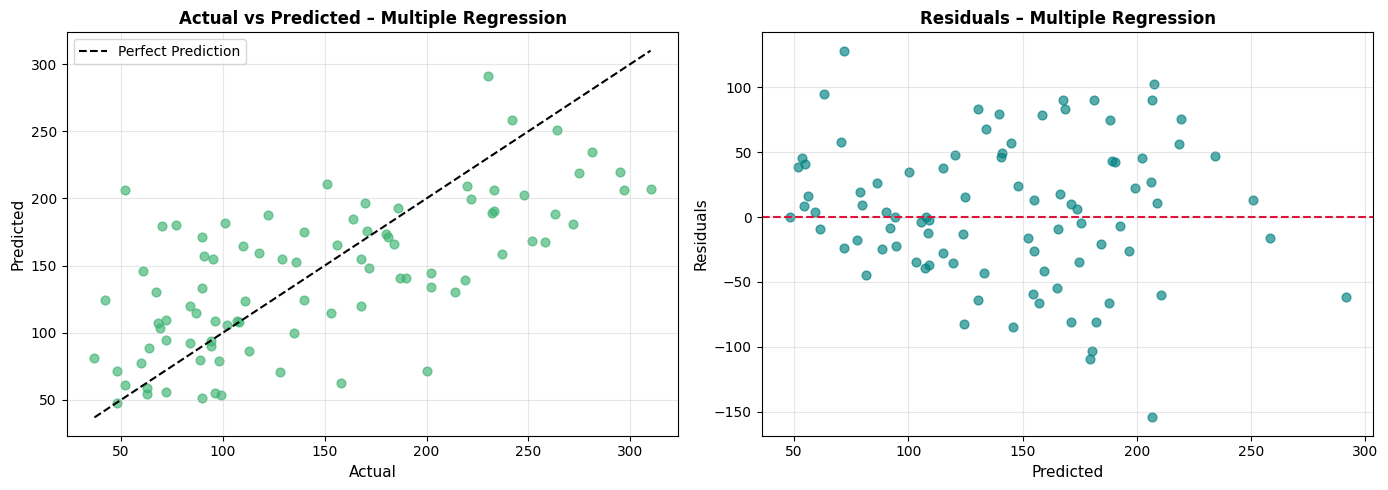

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test_m, y_pred_m, color='mediumseagreen', alpha=0.65, s=40)
mn, mx = y_test_m.min(), y_test_m.max()
axes[0].plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Perfect Prediction')
axes[0].set_xlabel('Actual', fontsize=11)
axes[0].set_ylabel('Predicted', fontsize=11)
axes[0].set_title('Actual vs Predicted – Multiple Regression', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_test_m - y_pred_m
axes[1].scatter(y_pred_m, residuals, color='teal', alpha=0.65, s=40)
axes[1].axhline(0, color='crimson', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('Residuals', fontsize=11)
axes[1].set_title('Residuals – Multiple Regression', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mlr_results.png', dpi=120, bbox_inches='tight')
plt.show()

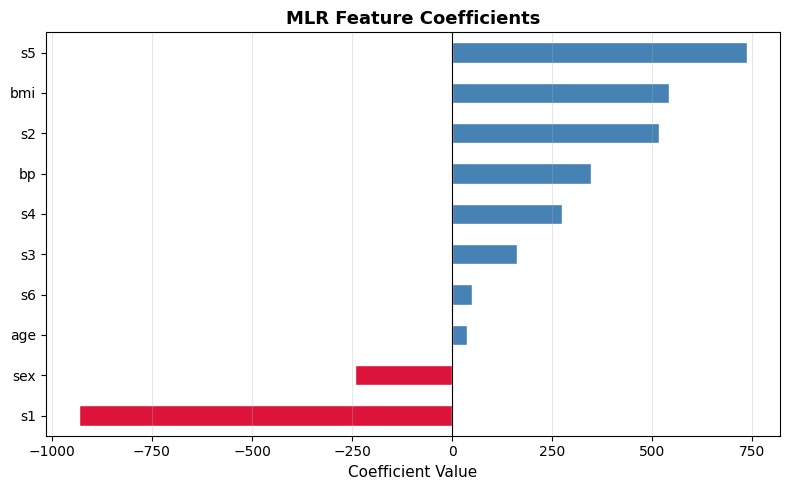

In [18]:
coef_series = pd.Series(mlr.coef_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['crimson' if c < 0 else 'steelblue' for c in coef_series]
coef_series.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('MLR Feature Coefficients', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value', fontsize=11)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('mlr_coefficients.png', dpi=120, bbox_inches='tight')
plt.show()

In [19]:
#Step 4 Polynomial Regression

degrees = [1, 2, 3, 5, 10]
poly_results = []

for deg in degrees:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ])
    pipe.fit(X_train_s, y_train_s)
    y_pred_p = pipe.predict(X_test_s)

    mae  = mean_absolute_error(y_test_s, y_pred_p)
    mse  = mean_squared_error(y_test_s, y_pred_p)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test_s, y_pred_p)

    poly_results.append({'Degree': deg, 'MAE': round(mae,4), 'MSE': round(mse,4),
                         'RMSE': round(rmse,4), 'R2': round(r2,4)})

    if deg in [1, 2, 3]:
        res_label = f'Polynomial Regression (degree={deg})'
        results.append({'Model': res_label, 'MAE': round(mae,4), 'MSE': round(mse,4),
                        'RMSE': round(rmse,4), 'R2': round(r2,4)})

poly_df = pd.DataFrame(poly_results)
print(poly_df.to_string(index=False))

 Degree     MAE       MSE    RMSE     R2
      1 52.2600 4061.8259 63.7325 0.2334
      2 52.3839 4085.0255 63.9142 0.2290
      3 52.1814 4064.4434 63.7530 0.2329
      5 51.8846 4085.8456 63.9206 0.2288
     10 52.9589 4315.5331 65.6927 0.1855


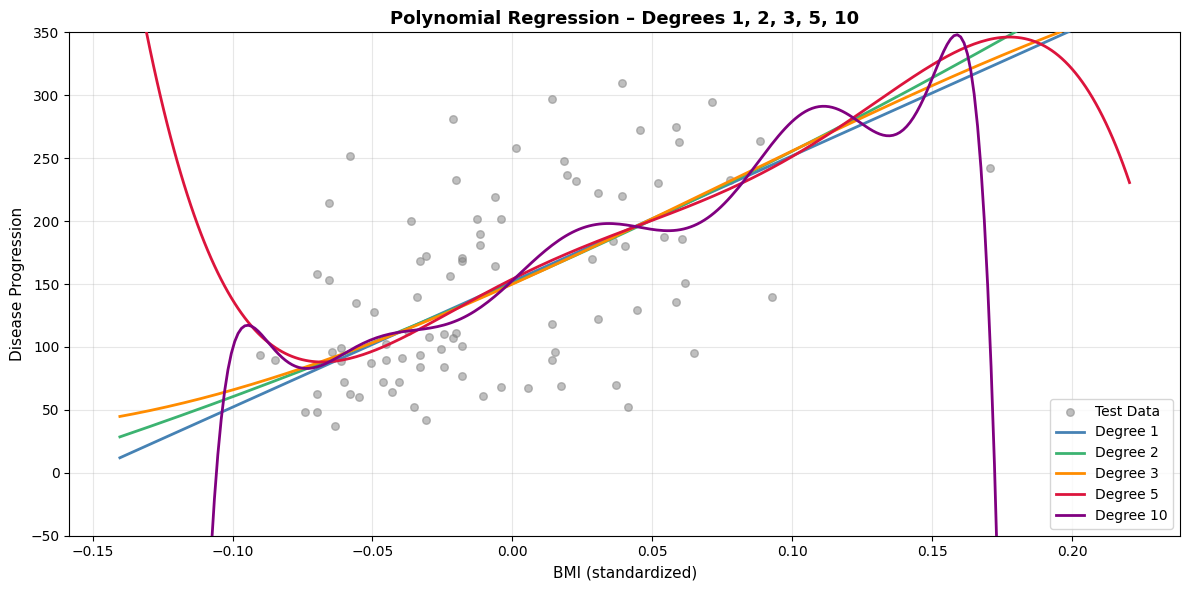

In [20]:
x_range = np.linspace(X_test_s['bmi'].min() - 0.05, X_test_s['bmi'].max() + 0.05, 300).reshape(-1, 1)
x_range_df = pd.DataFrame(x_range, columns=['bmi'])

plot_degrees = [1, 2, 3, 5, 10]
colors_map = {1:'steelblue', 2:'mediumseagreen', 3:'darkorange', 5:'crimson', 10:'purple'}

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(X_test_s['bmi'], y_test_s, color='gray', alpha=0.5, s=30, label='Test Data', zorder=3)

for deg in plot_degrees:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ])
    pipe.fit(X_train_s, y_train_s)
    y_line = pipe.predict(x_range_df)
    ax.plot(x_range, y_line, color=colors_map[deg], linewidth=2,
            label=f'Degree {deg}', zorder=4)

ax.set_xlabel('BMI (standardized)', fontsize=11)
ax.set_ylabel('Disease Progression', fontsize=11)
ax.set_title('Polynomial Regression – Degrees 1, 2, 3, 5, 10', fontsize=13, fontweight='bold')
ax.set_ylim(-50, 350)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('poly_regression.png', dpi=120, bbox_inches='tight')
plt.show()

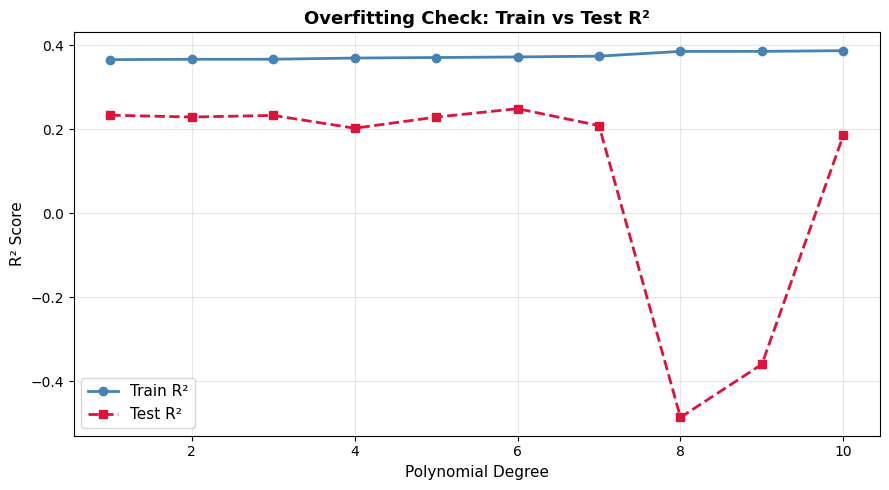

Train R² values: [0.366, 0.367, 0.367, 0.37, 0.371, 0.372, 0.374, 0.385, 0.385, 0.387]
Test  R² values: [0.233, 0.229, 0.233, 0.202, 0.229, 0.249, 0.209, -0.486, -0.36, 0.185]


In [21]:
train_r2, test_r2 = [], []

for deg in range(1, 11):
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ])
    pipe.fit(X_train_s, y_train_s)
    train_r2.append(r2_score(y_train_s, pipe.predict(X_train_s)))
    test_r2.append(r2_score(y_test_s, pipe.predict(X_test_s)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, 11), train_r2, 'o-', color='steelblue', label='Train R²', linewidth=2)
ax.plot(range(1, 11), test_r2, 's--', color='crimson', label='Test R²', linewidth=2)
ax.set_xlabel('Polynomial Degree', fontsize=11)
ax.set_ylabel('R² Score', fontsize=11)
ax.set_title('Overfitting Check: Train vs Test R²', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('poly_overfitting.png', dpi=120, bbox_inches='tight')
plt.show()

print("Train R² values:", [round(v,3) for v in train_r2])
print("Test  R² values:", [round(v,3) for v in test_r2])

In [23]:
#standardization
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_m)
X_test_sc  = scaler.transform(X_test_m)

In [24]:
#Ridge Regression
ridge_alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_res = []

print("Ridge Regression across alpha values:")
for a in ridge_alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_sc, y_train_m)
    yp = ridge.predict(X_test_sc)
    mae  = mean_absolute_error(y_test_m, yp)
    mse  = mean_squared_error(y_test_m, yp)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test_m, yp)
    ridge_res.append({'Alpha': a, 'MAE': round(mae,4), 'MSE': round(mse,4),
                      'RMSE': round(rmse,4), 'R2': round(r2,4)})
    if a == 1.0:
        results.append({'Model': 'Ridge (alpha=1)', 'MAE': round(mae,4),
                        'MSE': round(mse,4), 'RMSE': round(rmse,4), 'R2': round(r2,4)})

print(pd.DataFrame(ridge_res).to_string(index=False))

Ridge Regression across alpha values:
 Alpha     MAE       MSE    RMSE     R2
  0.01 42.7942 2900.0751 53.8523 0.4526
  0.10 42.7962 2899.0546 53.8429 0.4528
  1.00 42.8120 2892.0146 53.7775 0.4541
 10.00 42.8568 2875.7787 53.6263 0.4572
100.00 43.2507 2858.2243 53.4624 0.4605


In [25]:
#Lasso Regression

lasso_alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
lasso_res = []

print("Lasso Regression across alpha values:")
for a in lasso_alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_sc, y_train_m)
    yp = lasso.predict(X_test_sc)
    mae  = mean_absolute_error(y_test_m, yp)
    mse  = mean_squared_error(y_test_m, yp)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test_m, yp)
    lasso_res.append({'Alpha': a, 'MAE': round(mae,4), 'MSE': round(mse,4),
                      'RMSE': round(rmse,4), 'R2': round(r2,4)})
    if a == 1.0:
        results.append({'Model': 'Lasso (alpha=1)', 'MAE': round(mae,4),
                        'MSE': round(mse,4), 'RMSE': round(rmse,4), 'R2': round(r2,4)})

print(pd.DataFrame(lasso_res).to_string(index=False))

Lasso Regression across alpha values:
 Alpha     MAE       MSE    RMSE      R2
  0.01 42.7950 2898.3680 53.8365  0.4529
  0.10 42.8052 2884.6243 53.7087  0.4555
  1.00 42.8030 2824.5681 53.1467  0.4669
 10.00 44.7646 2933.8347 54.1649  0.4463
100.00 64.0065 5361.5335 73.2225 -0.0120


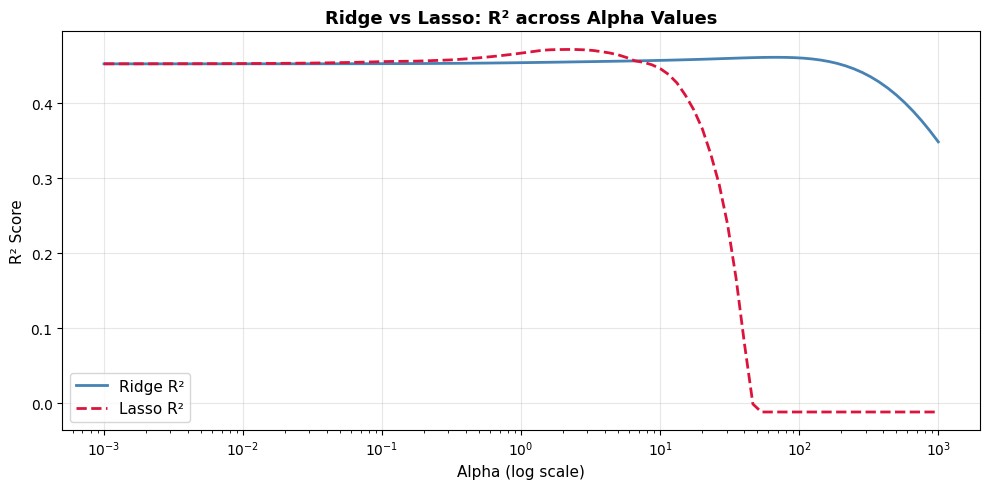

In [26]:
#  R^2 vs Alpha – Ridge and Lasso 
alphas_log = np.logspace(-3, 3, 100)
ridge_r2_list, lasso_r2_list = [], []

for a in alphas_log:
    r = Ridge(alpha=a).fit(X_train_sc, y_train_m)
    ridge_r2_list.append(r2_score(y_test_m, r.predict(X_test_sc)))
    l = Lasso(alpha=a, max_iter=10000).fit(X_train_sc, y_train_m)
    lasso_r2_list.append(r2_score(y_test_m, l.predict(X_test_sc)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(alphas_log, ridge_r2_list, color='steelblue', linewidth=2, label='Ridge R²')
ax.semilogx(alphas_log, lasso_r2_list, color='crimson', linewidth=2, linestyle='--', label='Lasso R²')
ax.set_xlabel('Alpha (log scale)', fontsize=11)
ax.set_ylabel('R² Score', fontsize=11)
ax.set_title('Ridge vs Lasso: R² across Alpha Values', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ridge_lasso_r2.png', dpi=120, bbox_inches='tight')
plt.show()

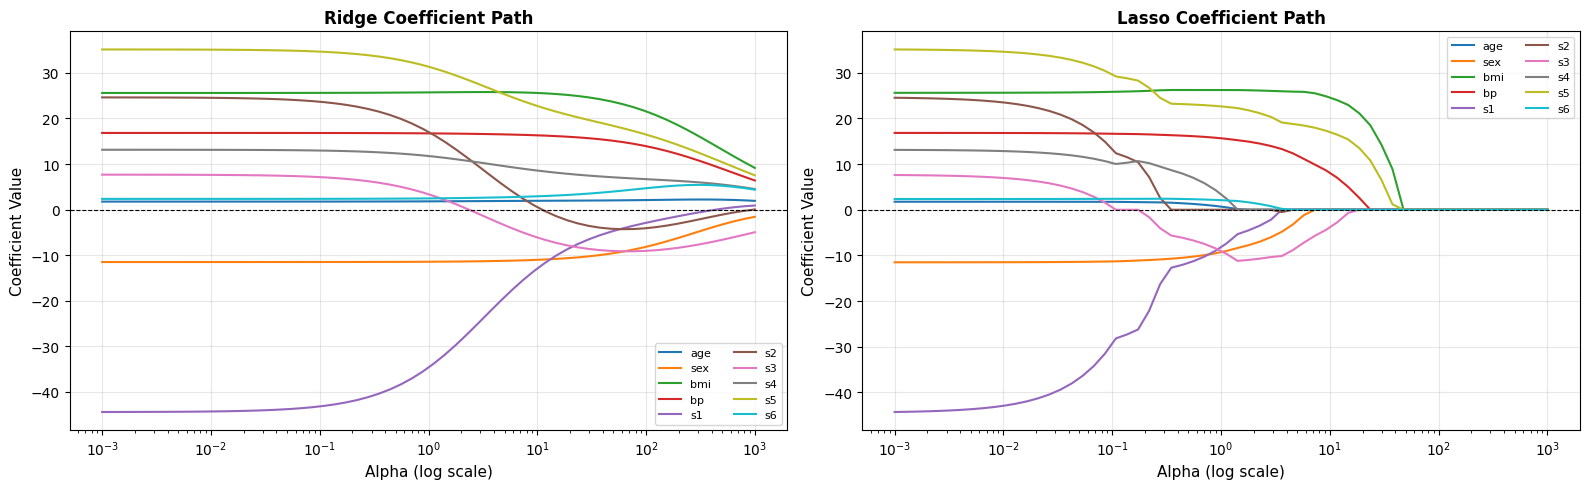

In [27]:

#the Coeffient Paths
ridge_coefs, lasso_coefs = [], []
alphas_path = np.logspace(-3, 3, 60)

for a in alphas_path:
    ridge_coefs.append(Ridge(alpha=a).fit(X_train_sc, y_train_m).coef_)
    lasso_coefs.append(Lasso(alpha=a, max_iter=10000).fit(X_train_sc, y_train_m).coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for i, fname in enumerate(X.columns):
    axes[0].semilogx(alphas_path, ridge_coefs[:, i], linewidth=1.5, label=fname)
    axes[1].semilogx(alphas_path, lasso_coefs[:, i], linewidth=1.5, label=fname)

for idx, title in enumerate(['Ridge Coefficient Path', 'Lasso Coefficient Path']):
    axes[idx].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[idx].set_xlabel('Alpha (log scale)', fontsize=11)
    axes[idx].set_ylabel('Coefficient Value', fontsize=11)
    axes[idx].set_title(title, fontsize=12, fontweight='bold')
    axes[idx].legend(fontsize=8, ncol=2)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('coefficient_paths.png', dpi=120, bbox_inches='tight')
plt.show()

Lasso coefficients (alpha=1) – zero = feature eliminated:
Feature  Lasso Coef
    age    0.687032
    sex   -9.297519
    bmi   26.219225
     bp   15.657314
     s1   -8.228172
     s2   -0.000000
     s3   -9.024087
     s4    3.420861
     s5   22.636465
     s6    2.098647

Features set to zero by Lasso: 1 / 10


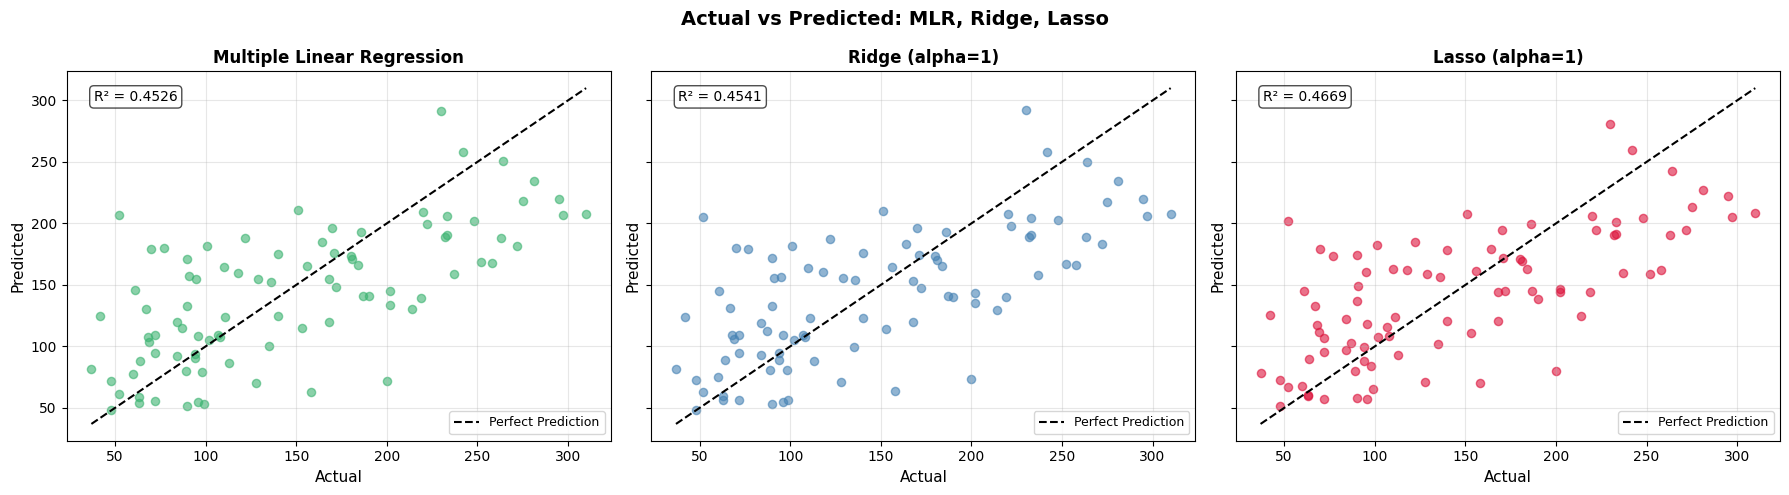

In [28]:

lasso_best = Lasso(alpha=1.0, max_iter=10000).fit(X_train_sc, y_train_m)
coef_df = pd.DataFrame({'Feature': X.columns, 'Lasso Coef': lasso_best.coef_})
print("Lasso coefficients (alpha=1) – zero = feature eliminated:")
print(coef_df.to_string(index=False))
n_zero = (lasso_best.coef_ == 0).sum()
print(f"\nFeatures set to zero by Lasso: {n_zero} / {len(X.columns)}")

ridge_best = Ridge(alpha=1.0).fit(X_train_sc, y_train_m)
y_pred_ridge = ridge_best.predict(X_test_sc)
y_pred_lasso = lasso_best.predict(X_test_sc)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
preds  = [y_pred_m, y_pred_ridge, y_pred_lasso]
titles = ['Multiple Linear Regression', 'Ridge (alpha=1)', 'Lasso (alpha=1)']
colors = ['mediumseagreen', 'steelblue', 'crimson']

for ax, pred, title, color in zip(axes, preds, titles, colors):
    ax.scatter(y_test_m, pred, color=color, alpha=0.6, s=35)
    mn, mx = y_test_m.min(), y_test_m.max()
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Perfect Prediction')
    ax.set_xlabel('Actual', fontsize=11)
    ax.set_ylabel('Predicted', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    r2 = r2_score(y_test_m, pred)
    ax.text(0.05, 0.92, f'R² = {r2:.4f}', transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle('Actual vs Predicted: MLR, Ridge, Lasso', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('regularization_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [29]:
results_df = pd.DataFrame(results)
print("\n=== MODEL COMPARISON SUMMARY ===")
print(results_df.to_string(index=False))


=== MODEL COMPARISON SUMMARY ===
                           Model     MAE       MSE    RMSE     R2
  Simple Linear Regression (BMI) 52.2600 4061.8259 63.7325 0.2334
      Multiple Linear Regression 42.7941 2900.1936 53.8534 0.4526
Polynomial Regression (degree=1) 52.2600 4061.8259 63.7325 0.2334
Polynomial Regression (degree=2) 52.3839 4085.0255 63.9142 0.2290
Polynomial Regression (degree=3) 52.1814 4064.4434 63.7530 0.2329
                 Ridge (alpha=1) 42.8120 2892.0146 53.7775 0.4541
                 Lasso (alpha=1) 42.8030 2824.5681 53.1467 0.4669


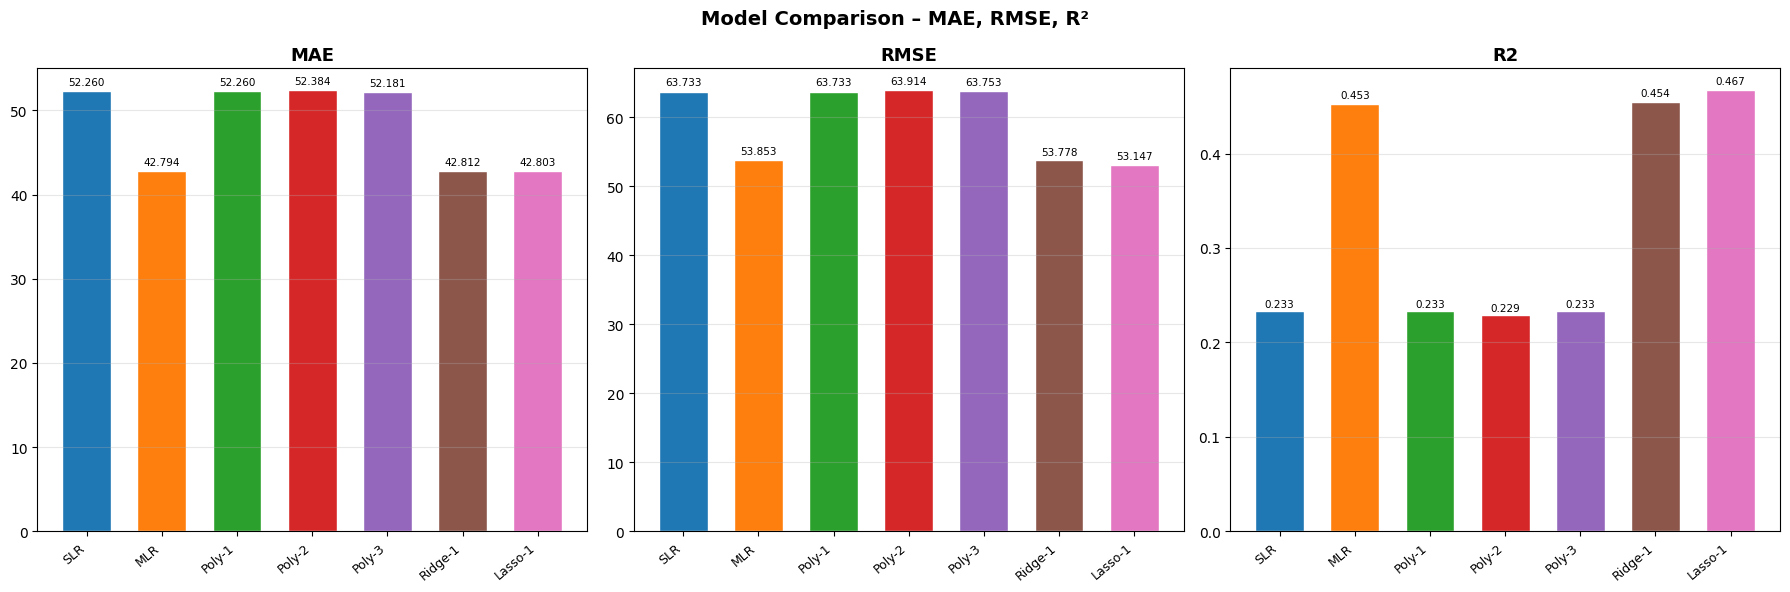

In [30]:
metrics = ['MAE', 'RMSE', 'R2']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

palette = plt.cm.tab10.colors
x = np.arange(len(results_df))
short_names = [
    'SLR', 'MLR',
    'Poly-1', 'Poly-2', 'Poly-3',
    'Ridge-1', 'Lasso-1'
]

for idx, metric in enumerate(metrics):
    bars = axes[idx].bar(x, results_df[metric], color=palette[:len(results_df)], edgecolor='white', width=0.65)
    axes[idx].set_title(metric, fontsize=13, fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(short_names, rotation=40, ha='right', fontsize=9)
    axes[idx].grid(True, axis='y', alpha=0.3)
    for bar in bars:
        h = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., h + 0.01*h,
                       f'{h:.3f}', ha='center', va='bottom', fontsize=7.5)

plt.suptitle('Model Comparison – MAE, RMSE, R²', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()